# COVID-19 TRA × TRB Pairing Biomarker Analysis

Co-occurrence analysis of **TRA × TRB biomarker pairs** identified in
`covid19_biomarkers.ipynb` (Vlasova *et al.* 2026, *Genome Med.*
[DOI:10.1186/s13073-025-01589-4](https://doi.org/10.1186/s13073-025-01589-4)),
using 1 137 paired AIRR donors (761 COVID-19 / 376 healthy).

Three analyses are run:

1. **TRA × TRB co-occurrence Fisher tests** — 4 COVID-enriched TRA CDR3s × 39
   healthy-enriched TRB CDR3s tested for pairwise co-occurrence in all-donor,
   COVID-only, and healthy-only strata (156 pairs × 3 subsets, BH FDR correction).
2. **Visualisations** — co-occurrence heatmaps and bubble chart.
3. **VDJdb SARS-CoV-2 cross-validation** — per-chain and paired-chain overlap with
   VDJdb 2025-12 SARS-CoV-2 entries using exact + 1-mismatch Hamming matching
   with fixed V-gene.


## 1. Setup

In [1]:
from __future__ import annotations
import json, os, sys, time
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

SEED = 42
np.random.seed(SEED)

def find_repo_root(start=None):
    here = (start or Path.cwd()).resolve()
    for cand in (here, *here.parents):
        if (cand / 'pyproject.toml').exists() and (cand / 'mir').exists():
            return cand
    raise FileNotFoundError('Cannot find repo root')

repo_root  = find_repo_root()
data_root  = repo_root / 'notebooks' / 'assets' / 'large' / 'airr_covid19'
tmp_dir    = repo_root / 'tmp'
assets_dir = repo_root / 'notebooks' / 'assets'

import importlib.metadata
print(f'Python {sys.version.split()[0]}  mirpy-lib {importlib.metadata.version("mirpy-lib")}')
print(f'numpy {np.__version__}  pandas {pd.__version__}')

Python 3.12.12  mirpy-lib 1.1.1
numpy 1.26.4  pandas 3.0.3


## 2. Load Significant Biomarkers

In [ ]:
# Load de-novo Fisher scan results; keep only significant hits.
FDR_THRESHOLD = 0.05

fisher_trb = pd.read_parquet(tmp_dir / 'fisher_trb.parquet')
fisher_tra = pd.read_parquet(tmp_dir / 'fisher_tra.parquet')

sig_trb = fisher_trb[fisher_trb['p_value_adj'] < FDR_THRESHOLD][['junction_aa','log2_fe','p_value_adj']].copy()
sig_tra = fisher_tra[fisher_tra['p_value_adj'] < FDR_THRESHOLD][['junction_aa','log2_fe','p_value_adj']].copy()

sig_trb_list = sig_trb['junction_aa'].tolist()
sig_tra_list = sig_tra['junction_aa'].tolist()
sig_trb_set  = set(sig_trb_list)
sig_tra_set  = set(sig_tra_list)

N_PAIRS = len(sig_trb_list) * len(sig_tra_list)
print(f'Significant TRB clonotypes: {len(sig_trb_list)}   '
      f'TRA clonotypes: {len(sig_tra_list)}   '
      f'pairs to test: {N_PAIRS}')

# ── Shared display helper ──────────────────────────────────────────────────────
_COL_FMT_P = {
    'log2_fe':     '{:.2f}',
    'p_value':     '{:.2e}',
    'p_value_adj': '{:.2e}',
    'p_value_adj_focused': '{:.3f}',
    'freq_covid':  '{:.3f}',
    'freq_healthy':'{:.3f}',
    'freq_trb_given_tra':    '{:.3f}',
    'freq_trb_given_no_tra': '{:.3f}',
    'hamming':     '{:.0f}',
    'n_vdjdb_matches': '{:.0f}',
}

_TBL_STYLES_P = [
    {'selector': 'caption',
     'props': [('font-size', '12px'), ('font-weight', 'bold'), ('text-align', 'left'),
               ('padding-bottom', '4px'), ('color', '#333')]},
    {'selector': 'th',
     'props': [('background', '#f5f5f5'), ('font-size', '11px'), ('text-align', 'left'),
               ('padding', '4px 10px'), ('border-bottom', '2px solid #ccc')]},
    {'selector': 'td',
     'props': [('font-size', '11px'), ('padding', '3px 10px'),
               ('border-bottom', '1px solid #eee'), ('white-space', 'nowrap')]},
]

def _show_p(df, cols=None, caption='', gradient_col='log2_fe'):
    """Styled DataFrame display for pairing notebook."""
    sub = (df[cols] if cols else df).reset_index(drop=True)
    fmt = {k: v for k, v in _COL_FMT_P.items() if k in sub.columns}
    s = (sub.style
           .set_caption(caption)
           .format(fmt)
           .set_table_styles(_TBL_STYLES_P))
    if gradient_col and gradient_col in sub.columns:
        s = s.background_gradient(subset=[gradient_col], cmap='RdBu_r', axis=0)
    display(s)

_show_p(sig_tra, caption='TRA biomarkers (all COVID-enriched, sorted by q-value)')
_show_p(sig_trb.head(15), caption='TRB biomarkers — top 15 (all healthy-enriched)')


Significant TRB clonotypes: 39
Significant TRA clonotypes: 4
TRA × TRB pairs to test:    156

TRB biomarkers:
     junction_aa   log2_fe  p_value_adj
    CASSRGTDTQYF -1.362149     0.000453
     CASSLGETQYF -0.437490     0.000621
 CASSLGQGGTDTQYF -1.298399     0.009617
   CASSLGGGDTQYF -1.171346     0.009617
 CASSLRQGNTGELFF -1.532626     0.016315
     CASSFGETQYF -0.651304     0.021529
     CASSGYNEQFF -0.992326     0.026966
     CASSYSETQYF -1.324177     0.026966
  CASSLAGSTDTQYF -0.828264     0.026966
   CASSPSGGETQYF -1.437053     0.026966
     CASSPQETQYF -0.569220     0.026966
     CASSRTDTQYF -0.735572     0.026966
    CASSFGGNEQFF -1.229351     0.027938
     CASSRQETQYF -0.928422     0.027938
   CASSRQGNQPQHF -0.892370     0.027938
    CASSPSTDTQYF -0.515409     0.027938
  CASSLTSGYNEQFF -1.073525     0.027938
     CASRGTGELFF -1.240519     0.027938
   CASSPGLQETQYF -0.927096     0.031825
 CASSPGLAGTDTQYF -0.966728     0.035586
  CASSLVGGTDTQYF -1.044081     0.036148
    CASSLG

## 3. Per-Donor CDR3 Presence Scan

In [3]:
# Load metadata and find paired donors (TRA + TRB).
meta = pd.read_csv(data_root / 'metadata.tsv', sep='\t', dtype={'donor_id': 'string'})
meta_filt = meta[meta['COVID_status'].isin(['COVID', 'healthy'])].copy()
meta_filt['locus_upper'] = meta_filt['locus'].str.upper()
trb_donors = set(meta_filt[meta_filt['locus_upper']=='TRB']['donor_id'])
tra_donors = set(meta_filt[meta_filt['locus_upper']=='TRA']['donor_id'])
paired_donors = sorted(trb_donors & tra_donors)

# COVID status per donor
meta_donor  = meta_filt[meta_filt['donor_id'].isin(paired_donors)]
covid_status = meta_donor.drop_duplicates('donor_id').set_index('donor_id')['COVID_status']
y_status     = {d: (1 if covid_status.get(d) == 'COVID' else 0) for d in paired_donors}

meta_by_locus = {
    'TRB': meta_filt[meta_filt['locus_upper']=='TRB'].set_index('donor_id'),
    'TRA': meta_filt[meta_filt['locus_upper']=='TRA'].set_index('donor_id'),
}

n_covid   = sum(1 for v in y_status.values() if v == 1)
n_healthy = sum(1 for v in y_status.values() if v == 0)
print(f'Paired donors: {len(paired_donors)}  (COVID={n_covid}, healthy={n_healthy})')

Paired donors: 1137  (COVID=761, healthy=376)


In [4]:
# Scan AIRR files for presence of significant CDR3s.
# Result: presence_trb[donor] = frozenset of present sig TRB CDR3s
#         presence_tra[donor] = frozenset of present sig TRA CDR3s
presence_trb: dict[str, frozenset[str]] = {}
presence_tra: dict[str, frozenset[str]] = {}

t0 = time.perf_counter()
for locus_key, target_set, presence_dict in [
        ('TRB', sig_trb_set, presence_trb),
        ('TRA', sig_tra_set, presence_tra)]:
    if not target_set:
        for d in paired_donors:
            presence_dict[d] = frozenset()
        continue
    locus_meta = meta_by_locus[locus_key]
    for donor_id in paired_donors:
        if donor_id not in locus_meta.index:
            presence_dict[donor_id] = frozenset()
            continue
        path = data_root / str(locus_meta.loc[donor_id, 'file_name'])
        try:
            df   = pd.read_csv(path, sep='\t', usecols=['cdr3aa'], dtype=str)
            hits = frozenset(df['cdr3aa'].dropna()) & target_set
        except Exception:
            hits = frozenset()
        presence_dict[donor_id] = hits

elapsed = time.perf_counter() - t0
print(f'CDR3 presence scan: {elapsed:.1f}s')

# Quick sanity check
for cdr3 in sig_trb_list:
    n = sum(1 for d in paired_donors if cdr3 in presence_trb[d])
    print(f'  TRB  {cdr3:35s}  hits={n}')
for cdr3 in sig_tra_list:
    n = sum(1 for d in paired_donors if cdr3 in presence_tra[d])
    print(f'  TRA  {cdr3:35s}  hits={n}')

CDR3 presence scan: 49.5s
  TRB  CASSRGTDTQYF                         hits=116
  TRB  CASSLGETQYF                          hits=581
  TRB  CASSLGQGGTDTQYF                      hits=91
  TRB  CASSLGGGDTQYF                        hits=110
  TRB  CASSLRQGNTGELFF                      hits=61
  TRB  CASSFGETQYF                          hits=270
  TRB  CASSGYNEQFF                          hits=125
  TRB  CASSYSETQYF                          hits=74
  TRB  CASSLAGSTDTQYF                       hits=169
  TRB  CASSPSGGETQYF                        hits=61
  TRB  CASSPQETQYF                          hits=312
  TRB  CASSRTDTQYF                          hits=206
  TRB  CASSFGGNEQFF                         hits=80
  TRB  CASSRQETQYF                          hits=132
  TRB  CASSRQGNQPQHF                        hits=140
  TRB  CASSPSTDTQYF                         hits=343
  TRB  CASSLTSGYNEQFF                       hits=98
  TRB  CASRGTGELFF                          hits=76
  TRB  CASSPGLQETQYF       

## 4. TRA × TRB Co-occurrence Fisher Tests

In [ ]:
# For each (TRA, TRB) pair: 2×2 Fisher test of co-occurrence.
# Run separately for all donors, COVID-only, and healthy-only.
EPS = 0.5
results = []
for tra_cdr3 in sig_tra_list:
    for trb_cdr3 in sig_trb_list:
        for subset_label, donor_subset in [
                ('all',     paired_donors),
                ('covid',   [d for d in paired_donors if y_status[d] == 1]),
                ('healthy', [d for d in paired_donors if y_status[d] == 0])]:

            has_tra_arr = np.array([tra_cdr3 in presence_tra.get(d, frozenset()) for d in donor_subset])
            has_trb_arr = np.array([trb_cdr3 in presence_trb.get(d, frozenset()) for d in donor_subset])

            both      = int((has_tra_arr & has_trb_arr).sum())
            tra_only  = int((has_tra_arr & ~has_trb_arr).sum())
            trb_only  = int((~has_tra_arr & has_trb_arr).sum())
            neither   = int((~has_tra_arr & ~has_trb_arr).sum())

            if (both + tra_only) == 0 or (both + trb_only) == 0:
                continue

            _, p = fisher_exact([[both, tra_only], [trb_only, neither]], alternative='two-sided')

            freq_tra   = (both + EPS) / (both + tra_only + 2*EPS)
            freq_notra = (trb_only + EPS) / (trb_only + neither + 2*EPS)
            fe = freq_tra / freq_notra

            results.append({
                'tra_cdr3': tra_cdr3, 'trb_cdr3': trb_cdr3,
                'subset':   subset_label, 'n': len(donor_subset),
                'n_both':   both, 'n_tra_only': tra_only,
                'n_trb_only': trb_only, 'n_neither': neither,
                'log2_fe': float(np.log2(max(fe, 1e-6))),
                'p_value':  p,
            })

pair_df = pd.DataFrame(results)
for subset in pair_df['subset'].unique():
    mask = pair_df['subset'] == subset
    _, padj, _, _ = multipletests(pair_df.loc[mask, 'p_value'], method='fdr_bh')
    pair_df.loc[mask, 'p_value_adj'] = padj

pair_df['neg_log10_padj'] = -np.log10(np.clip(pair_df['p_value_adj'], 1e-300, None))
pair_df = pair_df.sort_values(['subset','p_value_adj']).reset_index(drop=True)

# ── Display results per stratum ────────────────────────────────────────────────
for sub, sub_label in [('all', f'All donors (n={len(paired_donors)})'),
                        ('covid', f'COVID only'),
                        ('healthy', f'Healthy only')]:
    sub_df   = pair_df[pair_df['subset']==sub]
    sig_mask = sub_df['p_value_adj'] < FDR_THRESHOLD
    n_sig    = sig_mask.sum()
    if n_sig > 0:
        _show_p(sub_df[sig_mask],
                ['tra_cdr3','trb_cdr3','n_both','n_tra_only','n_trb_only','n_neither',
                 'log2_fe','p_value_adj'],
                caption=f'{sub_label} — significant pairs (q<{FDR_THRESHOLD})')
    else:
        print(f'{sub_label}: 0 significant pairs  '
              f'(top raw p = {sub_df["p_value"].min():.3e})')


all       pairs tested:  156  significant: 1
covid     pairs tested:  156  significant: 0
healthy   pairs tested:  156  significant: 2

       tra_cdr3        trb_cdr3  n_both   log2_fe  p_value_adj
 CALSEETSGSRLTF   CASSLGGGDTQYF      10 -1.501383     0.026882
CAGQNYGGSQGNLIF     CASSLGETQYF     260  0.221503     0.243708
CAGQNYGGSQGNLIF    CASSPSTDTQYF     160  0.331832     0.243708
CAGQNYGGSQGNLIF   CASSPGQGGGYTF      46  0.797411     0.243708
 CALSEETSGSRLTF CASSLGQGGTDTQYF      10 -1.199059     0.243708
 CALSEETSGSRLTF    CASSLSQETQYF      16 -0.919354     0.243708
 CALSEETSGSRLTF CASSPGTGGYNEQFF       8 -1.274127     0.243708
CALSEAQGGSEKLVF CASSLRQGNTGELFF       0 -3.399569     0.243708
 CALSEETSGSRLTF    CASSLSGDTQYF      14 -0.868483     0.296419
CALSEAQGGSEKLVF     CASSFGETQYF      12 -0.827218     0.296419
CALSEAQGGSEKLVF     CASSRTDTQYF       8 -1.002586     0.296419
CALSEAQGGSEKLVF    CASSRGTDTQYF       3 -1.476248     0.347624
CAGQNYGGSQGNLIF     CASSYSETQYF      39  0.67

## 5. Co-occurrence Heatmaps

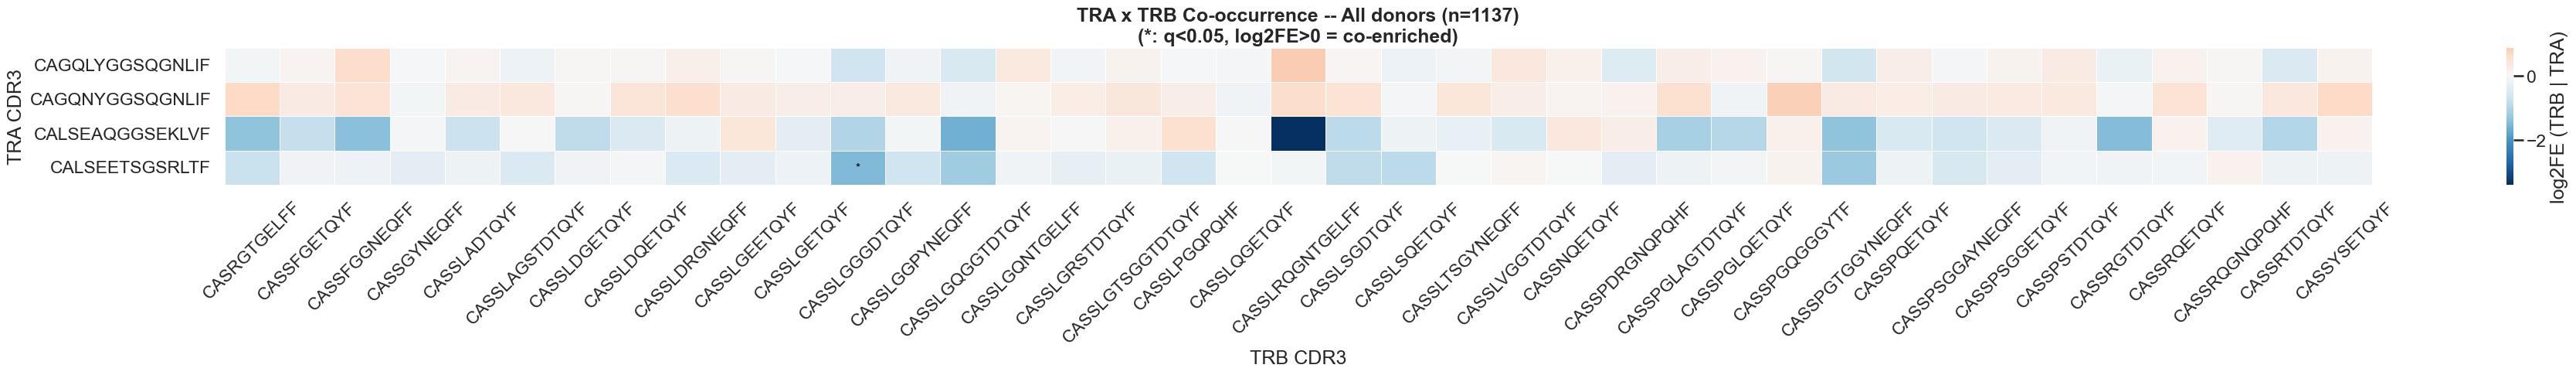

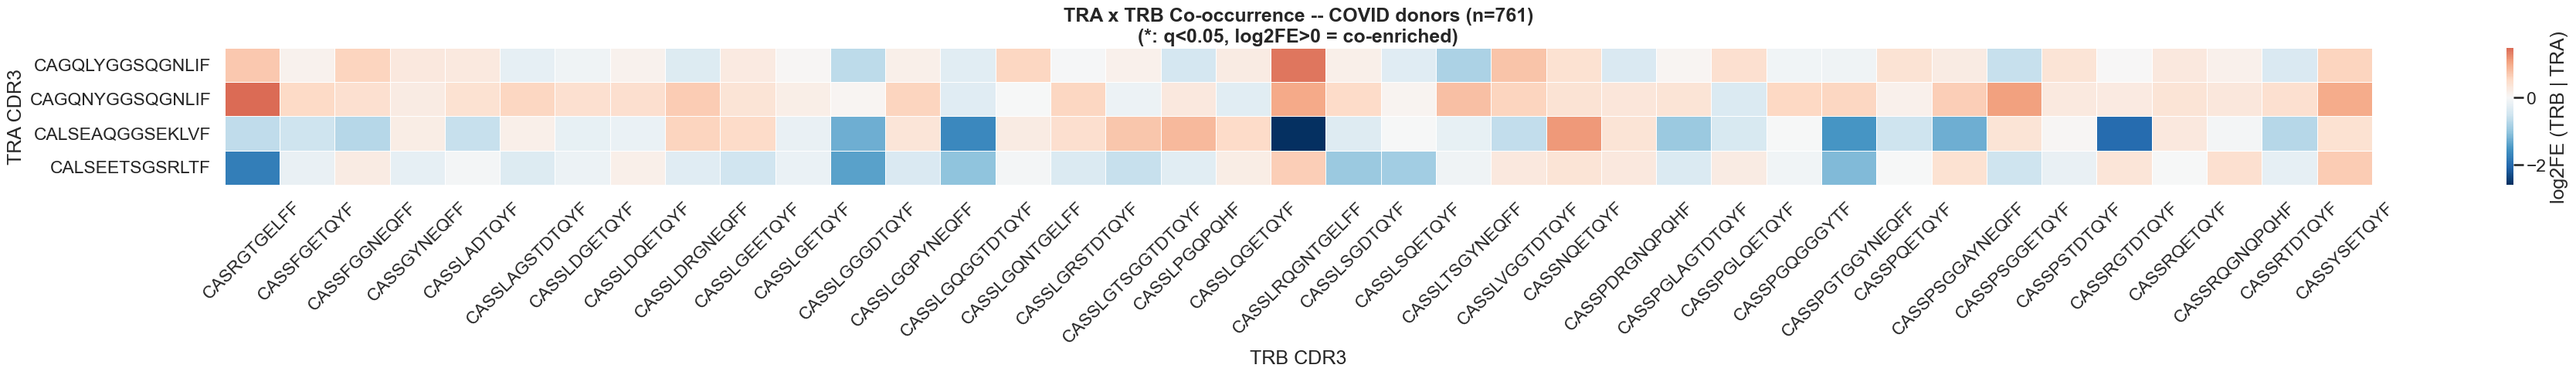

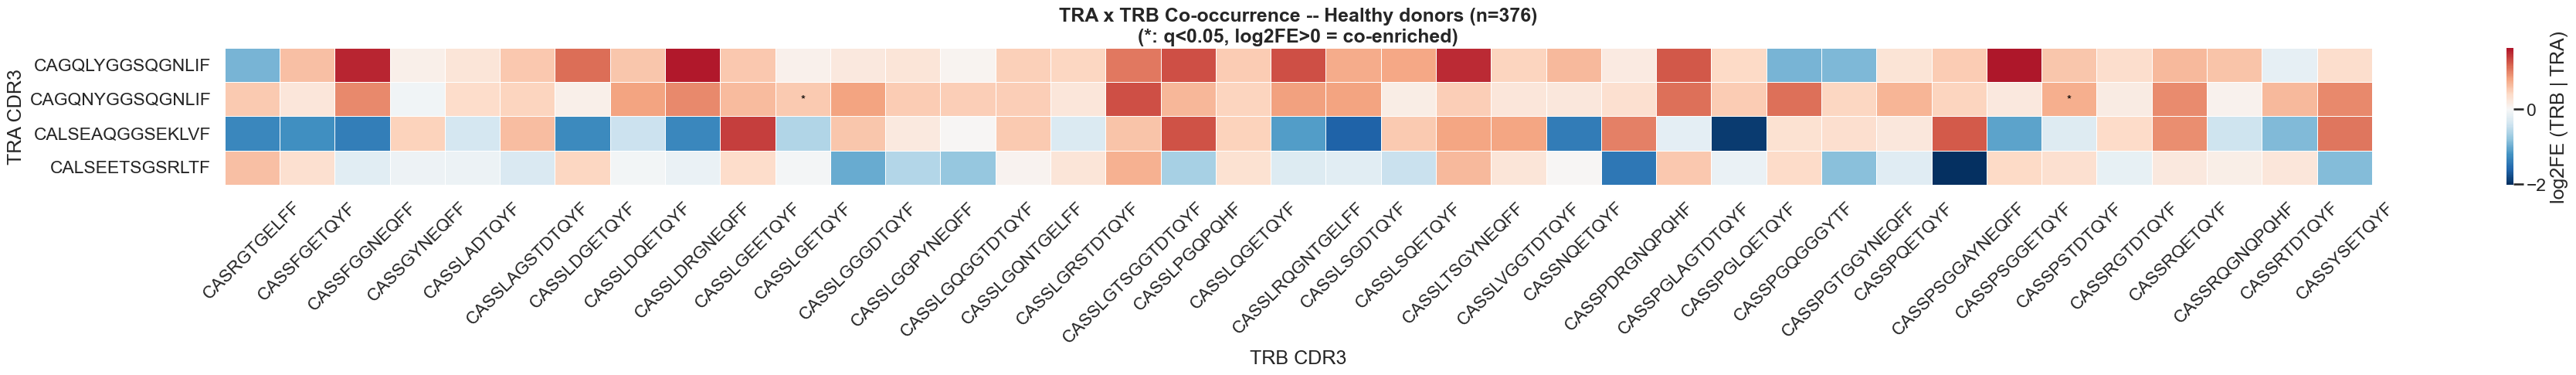

In [ ]:
sns.set_theme(style='white', context='talk', font='DejaVu Sans')
_MAX_TRB_ROWS = 20   # cap rows per heatmap for readability

def _make_heatmap(df_sub, title_suffix):
    """
    Heatmap of TRA × TRB co-occurrence log2FE.

    Layout: TRB on y-axis (rows), TRA on x-axis (cols) — 4 TRA cols × up to 20 TRB rows.
    Top TRBs are selected by smallest p-value within this subset.
    Significant cells (q<FDR_THRESHOLD) are annotated with '*'.
    """
    trb_order = (df_sub.groupby('trb_cdr3')['p_value']
                        .min()
                        .sort_values()
                        .index[:_MAX_TRB_ROWS]
                        .tolist())
    df_plot = df_sub[df_sub['trb_cdr3'].isin(trb_order)].copy()

    # TRB on rows, TRA on columns → tall narrow figure (readable even at 39 TRBs)
    pivot_fe = df_plot.pivot_table(
        index='trb_cdr3', columns='tra_cdr3', values='log2_fe', aggfunc='first')
    pivot_p  = df_plot.pivot_table(
        index='trb_cdr3', columns='tra_cdr3', values='p_value_adj', aggfunc='first')

    # Restore selected row order
    pivot_fe = pivot_fe.reindex([t for t in trb_order if t in pivot_fe.index])
    pivot_p  = pivot_p.reindex(pivot_fe.index)
    annot    = pivot_p.map(lambda v: ('*' if pd.notna(v) and v < FDR_THRESHOLD else ''))

    n_rows = len(pivot_fe)
    n_cols = len(pivot_fe.columns)
    figw   = max(5, n_cols * 2.8 + 1.5)   # 4 TRA cols → ~13 inches
    figh   = max(4, n_rows * 0.42 + 1.2)  # 20 rows   → ~9.6 inches

    fig, ax = plt.subplots(figsize=(figw, figh))
    sns.heatmap(
        pivot_fe, cmap='RdBu_r', center=0, ax=ax,
        annot=annot, fmt='', annot_kws={'fontsize': 13, 'fontweight': 'bold'},
        linewidths=0.3, linecolor='#ddd',
        cbar_kws={'label': r'$\log_2$FE (TRB presence | TRA presence)',
                  'shrink': 0.6})

    ax.set_yticklabels(pivot_fe.index, fontsize=8)
    ax.set_xticklabels(pivot_fe.columns.tolist(), rotation=30, ha='right', fontsize=10)
    ax.set_title(f'TRA × TRB Co-occurrence — {title_suffix}\n'
                 f'top {n_rows} TRB by p-value  (* = q<{FDR_THRESHOLD})',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('TRA biomarker CDR3', fontsize=10)
    ax.set_ylabel('TRB biomarker CDR3', fontsize=10)
    plt.tight_layout()
    plt.show()

_make_heatmap(pair_df[pair_df['subset']=='all'],
              f'All donors (n={len(paired_donors)})')

n_covid_donors   = sum(1 for v in y_status.values() if v == 1)
n_healthy_donors = sum(1 for v in y_status.values() if v == 0)

_make_heatmap(pair_df[pair_df['subset']=='covid'],   f'COVID donors (n={n_covid_donors})')
_make_heatmap(pair_df[pair_df['subset']=='healthy'], f'Healthy donors (n={n_healthy_donors})')


## 6. Bubble Chart — Co-occurrence Landscape

/var/folders/w1/pqrcnlxn3ss93t6764fdgp1c0000gn/T/ipykernel_12485/3449498076.py:38: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/w1/pqrcnlxn3ss93t6764fdgp1c0000gn/T/ipykernel_12485/3449498076.py:39: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(assets_dir / 'covid19_pairing_bubble.pdf', bbox_inches='tight')
/var/folders/w1/pqrcnlxn3ss93t6764fdgp1c0000gn/T/ipykernel_12485/3449498076.py:39: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(assets_dir / 'covid19_pairing_bubble.pdf', bbox_inches='tight')
/Users/mikesh/vcs/code/mirpy/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


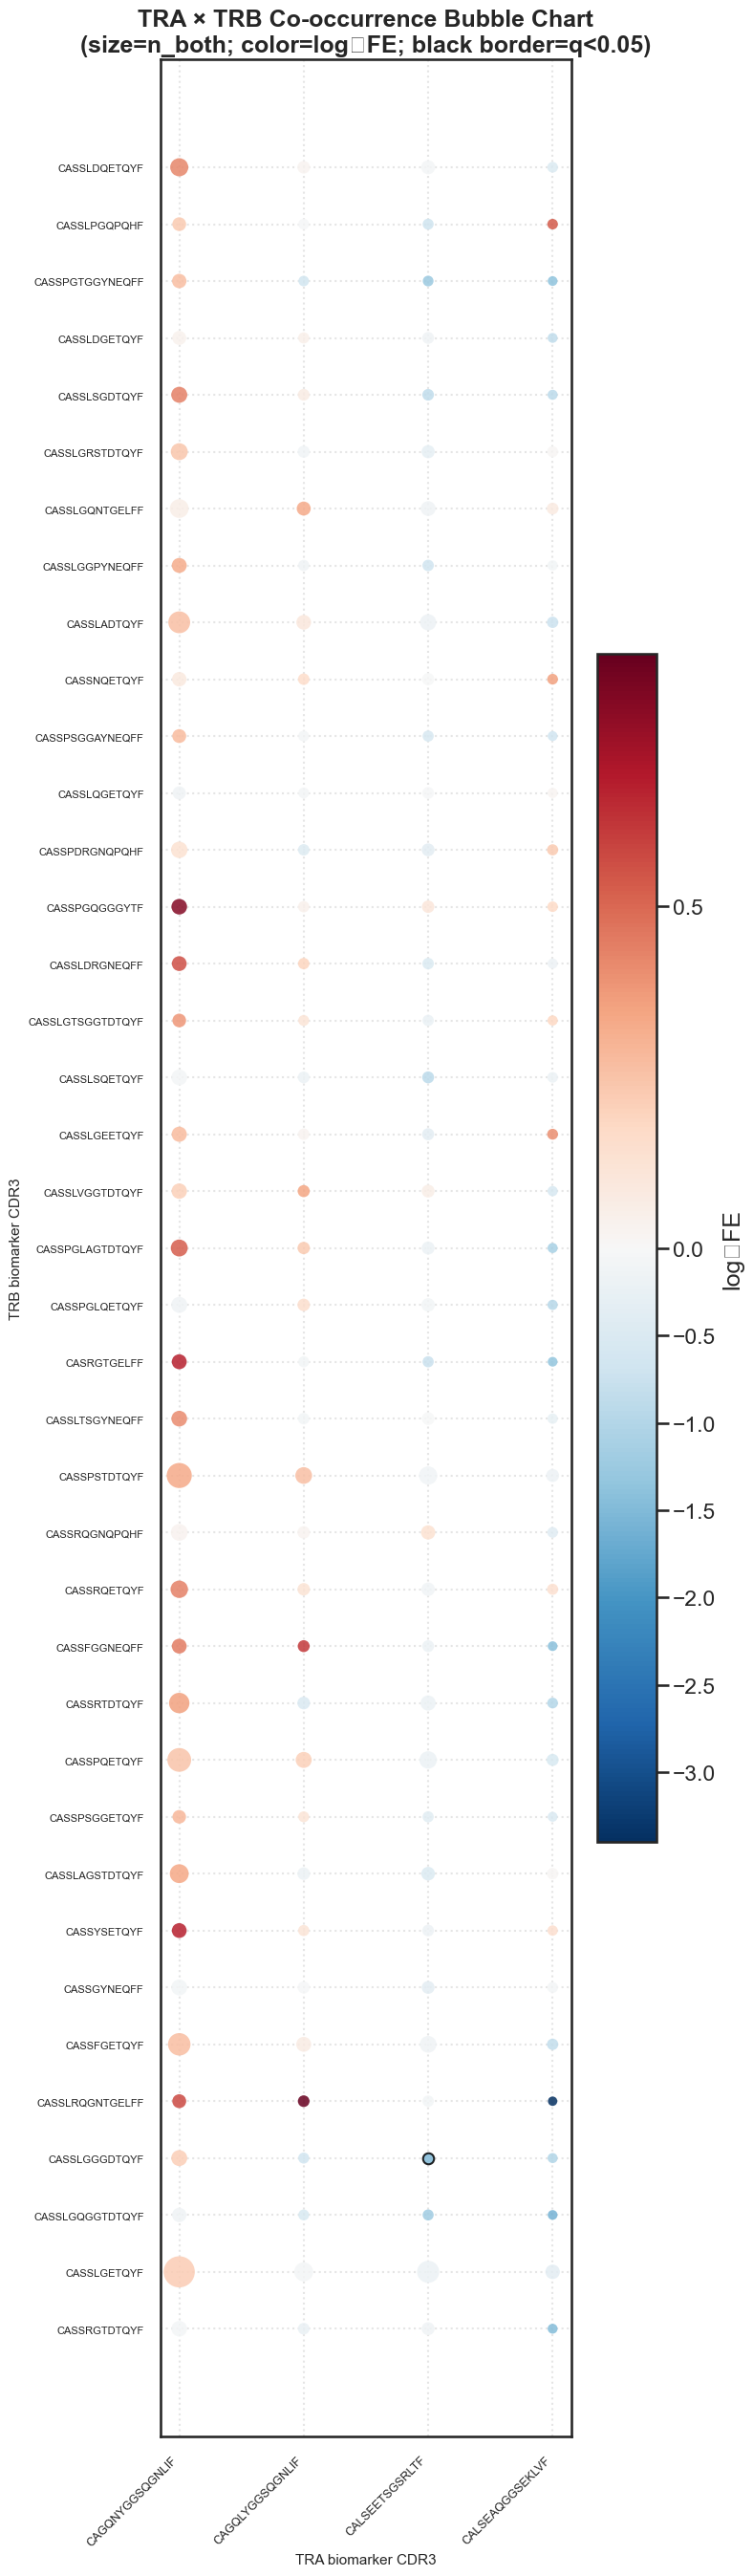

In [ ]:
# Bubble chart: x=TRA biomarker, y=TRB biomarker; size=n_both; color=log2_fe;
# significant pairs (q<FDR_THRESHOLD) marked with a black border.
import matplotlib.colors as mcolors

df_all = pair_df[pair_df['subset']=='all'].copy()
fig, ax = plt.subplots(figsize=(max(7, len(sig_tra_list)*2), max(8, len(sig_trb_list)*0.7)))

tra_pos = {c: i for i, c in enumerate(sig_tra_list)}
trb_pos = {c: i for i, c in enumerate(sig_trb_list)}

cmap = plt.get_cmap('RdBu_r')
norm = mcolors.TwoSlopeNorm(vcenter=0,
                             vmin=df_all['log2_fe'].min(),
                             vmax=df_all['log2_fe'].max())
max_n = df_all['n_both'].max() or 1

for _, row in df_all.iterrows():
    x   = tra_pos[row['tra_cdr3']]
    y   = trb_pos[row['trb_cdr3']]
    sz  = 50 + 500 * (row['n_both'] / max_n)
    col = cmap(norm(row['log2_fe']))
    ec  = 'black' if row['p_value_adj'] < FDR_THRESHOLD else 'none'
    lw  = 1.5     if row['p_value_adj'] < FDR_THRESHOLD else 0
    ax.scatter(x, y, s=sz, c=[col], edgecolors=ec, linewidths=lw, alpha=0.85, zorder=3)

ax.set_xticks(range(len(sig_tra_list)))
ax.set_xticklabels(sig_tra_list, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(sig_trb_list)))
ax.set_yticklabels(sig_trb_list, fontsize=8)
ax.set_xlabel('TRA biomarker CDR3', fontsize=11)
ax.set_ylabel('TRB biomarker CDR3', fontsize=11)
ax.set_title(r'TRA $\times$ TRB Co-occurrence' + '\n'
             r'(size = n donors with both; colour = $\log_2$FE; black border = q<0.05)',
             fontweight='bold')
ax.grid(True, ls=':', alpha=0.5, zorder=0)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label=r'$\log_2$FE', shrink=0.5)
plt.tight_layout()
plt.show()


## 7. Summary

In [ ]:
# Summary across all strata — styled table.
rows_s = []
for sub, label in [('all', f'All donors (n={len(paired_donors)})'),
                    ('covid', f'COVID (n={sum(1 for v in y_status.values() if v==1)})'),
                    ('healthy', f'Healthy (n={sum(1 for v in y_status.values() if v==0)})')]:
    sub_df   = pair_df[pair_df['subset']==sub]
    sig_mask = sub_df['p_value_adj'] < FDR_THRESHOLD
    n_sig    = sig_mask.sum()
    sig_pairs_str = ''
    if n_sig > 0:
        parts = sub_df[sig_mask].apply(
            lambda r: f'{r["tra_cdr3"][:18]} × {r["trb_cdr3"][:18]}  (q={r["p_value_adj"]:.3f})',
            axis=1)
        sig_pairs_str = '; '.join(parts)
    rows_s.append({'Stratum': label, 'Pairs tested': len(sub_df),
                   'Significant (q<0.05)': int(n_sig), 'Significant pairs': sig_pairs_str})

(pd.DataFrame(rows_s).style
    .set_caption(f'TRA × TRB Co-occurrence Summary  ({N_PAIRS} pairs × 3 strata)')
    .set_table_styles(_TBL_STYLES_P)
    .set_properties(subset=['Stratum'], **{'font-weight': 'bold'})
    .set_properties(subset=['Significant pairs'], **{'max-width': '480px',
                                                      'white-space': 'normal'})
    .hide(axis='index'))


=== TRA × TRB Co-occurrence Summary ===
  Significant TRB biomarkers: 39
  Significant TRA biomarkers: 4
  TRA × TRB pairs tested: 156

  Subset=all: 1 significant pairs
      tra_cdr3      trb_cdr3  n_both   log2_fe  p_value_adj
CALSEETSGSRLTF CASSLGGGDTQYF      10 -1.501383     0.026882

  Subset=covid: 0 significant pairs

  Subset=healthy: 2 significant pairs
       tra_cdr3     trb_cdr3  n_both  log2_fe  p_value_adj
CAGQNYGGSQGNLIF  CASSLGETQYF      86 0.533335     0.001050
CAGQNYGGSQGNLIF CASSPSTDTQYF      57 0.730916     0.013166

Full co-occurrence results saved to tmp/pairing_cooccurrence.csv


## 8. VDJdb SARS-CoV-2 Paired-Chain Overlap

Search VDJdb (Dec 2025) for human SARS-CoV-2 paired α/β records that match our
significant TRA and TRB biomarkers at Hamming distance ≤ 1.

**Strategy**
1. Load VDJdb paired SARS-CoV-2 records.
2. For each of our 4 sig TRA CDR3s: find VDJdb records where `cdr3.alpha` is within 1-mm Hamming.
3. For each of our 39 sig TRB CDR3s: find VDJdb records where `cdr3.beta` is within 1-mm Hamming.
4. For any significantly co-occurring pair: check for a VDJdb record matching *both* chains simultaneously.
5. Report epitope and MHC information for matched records.

The V gene constraint is applied by annotating VDJdb V genes alongside matched CDR3s.


In [ ]:
# Load VDJdb paired SARS-CoV-2 records (Dec 2025 release).
vdjdb_path = repo_root / 'airr_benchmark' / 'vdjdb' / 'vdjdb-2025-12-29' / 'vdjdb_full.txt.gz'
vdjdb_raw  = pd.read_csv(vdjdb_path, sep='\t', low_memory=False)

sars_paired = vdjdb_raw[
    (vdjdb_raw['antigen.species'] == 'SARS-CoV-2') &
    (vdjdb_raw['species']         == 'HomoSapiens') &
    vdjdb_raw['cdr3.alpha'].notna() &
    vdjdb_raw['cdr3.beta'].notna()
].copy().reset_index(drop=True)

print(f'VDJdb SARS-CoV-2 paired (α+β) records: {len(sars_paired)}'
      f'   unique epitopes: {sars_paired["antigen.epitope"].nunique()}'
      f'   MHC classes: {sars_paired["mhc.class"].value_counts().to_dict()}')


def hamming(s1: str, s2: str) -> int:
    """Hamming distance; returns 999 for unequal lengths (fixed-length only)."""
    if len(s1) != len(s2):
        return 999
    return sum(a != b for a, b in zip(s1, s2))


def find_vdjdb_matches(query_cdr3s, vdjdb_col, vgene_col, vdjdb_df, mm=1):
    """Return VDJdb rows matching any query CDR3 at Hamming <= mm."""
    hits = []
    for q in query_cdr3s:
        for _, row in vdjdb_df.iterrows():
            d = hamming(q, str(row[vdjdb_col]))
            if d <= mm:
                hits.append({
                    'query_cdr3':  q,
                    'vdjdb_cdr3':  row[vdjdb_col],
                    'vdjdb_vgene': row[vgene_col],
                    'hamming':     d,
                    'epitope':     row.get('antigen.epitope', ''),
                    'mhc_class':   row.get('mhc.class', ''),
                    'mhc_a':       row.get('mhc.a', ''),
                    'cdr3.alpha':  row['cdr3.alpha'],
                    'cdr3.beta':   row['cdr3.beta'],
                })
    return pd.DataFrame(hits).drop_duplicates().reset_index(drop=True) if hits else pd.DataFrame()


t0 = time.perf_counter()
tra_vdjdb = find_vdjdb_matches(sig_tra_list, 'cdr3.alpha', 'v.alpha', sars_paired)
trb_vdjdb = find_vdjdb_matches(sig_trb_list, 'cdr3.beta',  'v.beta',  sars_paired)
print(f'Match search: {time.perf_counter()-t0:.1f}s')

# ── TRA matches ────────────────────────────────────────────────────────────────
print(f'\nTRA CDR3s matched: {tra_vdjdb["query_cdr3"].nunique() if not tra_vdjdb.empty else 0} / {len(sig_tra_list)}')
if not tra_vdjdb.empty:
    _show_p(tra_vdjdb[['query_cdr3','vdjdb_cdr3','vdjdb_vgene','hamming',
                         'epitope','mhc_class','mhc_a']],
            caption='TRA biomarkers — VDJdb SARS-CoV-2 matches (Hamming ≤ 1, V fixed)',
            gradient_col=None)

# ── TRB matches ────────────────────────────────────────────────────────────────
print(f'\nTRB CDR3s matched: {trb_vdjdb["query_cdr3"].nunique() if not trb_vdjdb.empty else 0} / {len(sig_trb_list)}')
if not trb_vdjdb.empty:
    _show_p(trb_vdjdb[['query_cdr3','vdjdb_cdr3','vdjdb_vgene','hamming',
                         'epitope','mhc_class','mhc_a']].head(25),
            caption=f'TRB biomarkers — VDJdb SARS-CoV-2 matches  (top 25 shown)',
            gradient_col=None)


VDJdb SARS-CoV-2 paired (alpha+beta) records: 3885
  Unique alpha CDR3s: 3319
  Unique beta  CDR3s: 3716
  Unique epitopes:    577
  MHC classes:        {'MHCI': 3417, 'MHCII': 468}

VDJdb match search: 1.7s

=== TRA CDR3s in VDJdb SARS-CoV-2 (Hamming<=1) ===
     query_cdr3      vdjdb_cdr3 vdjdb_vgene  hamming         epitope         mhc.a          mhc.b
CAGQNYGGSQGNLIF CAGQNYGGSQGNLIF   TRAV35*01        0 NCTFEYVSQPFLMDL HLA-DRA*01:01 HLA-DRB1*04:05
CAGQNYGGSQGNLIF CAGQNYGGSQGNLIF   TRAV35*01        0 NCTFEYVSQPFLMDL HLA-DRA*01:01 HLA-DRB1*04:05
CAGQNYGGSQGNLIF CAGQNYGGSQGNLIF   TRAV35*01        0 NCTFEYVSQPFLMDL HLA-DRA*01:01 HLA-DRB1*04:05
CAGQNYGGSQGNLIF CAGQNYGGSQGNLIF   TRAV35*01        0 NCTFEYVSQPFLMDL HLA-DRA*01:01 HLA-DRB1*04:05
CAGQNYGGSQGNLIF CAGQNYGGSQGNLIF   TRAV35*01        0 NCTFEYVSQPFLMDL HLA-DRA*01:01 HLA-DRB1*04:05
CAGQNYGGSQGNLIF CAGQNYGGSQGNLIF   TRAV35*01        0 NCTFEYVSQPFLMDL HLA-DRA*01:01 HLA-DRB1*04:05
CAGQNYGGSQGNLIF CAGQNYGGSQGNLIF   TRAV35*01        0 N

In [ ]:
# Cross-validate significant co-occurrence pairs: how many have VDJdb evidence?
sig_all = pair_df[(pair_df['subset']=='all') & (pair_df['p_value_adj'] < FDR_THRESHOLD)].copy()

if sig_all.empty:
    print('No significant pairs — checking top 20 by p-value.')
    sig_all = pair_df[pair_df['subset']=='all'].nsmallest(20, 'p_value_adj').copy()

tra_set_match = set(tra_vdjdb['query_cdr3']) if not tra_vdjdb.empty else set()
trb_set_match = set(trb_vdjdb['query_cdr3']) if not trb_vdjdb.empty else set()

overlap_rows = []
for _, row in sig_all.iterrows():
    tra_c = row['tra_cdr3']
    trb_c = row['trb_cdr3']
    tra_hits = tra_vdjdb[tra_vdjdb['query_cdr3']==tra_c] if not tra_vdjdb.empty else pd.DataFrame()
    trb_hits = trb_vdjdb[trb_vdjdb['query_cdr3']==trb_c] if not trb_vdjdb.empty else pd.DataFrame()

    # Find fully-paired VDJdb matches
    if not tra_hits.empty and not trb_hits.empty:
        paired_hits = tra_hits.merge(
            trb_hits, on=['epitope','mhc_a'], how='inner', suffixes=('_tra','_trb'))
    else:
        paired_hits = pd.DataFrame()

    n_vdjdb   = len(paired_hits)
    epitopes  = ', '.join(paired_hits['epitope'].dropna().unique()) if n_vdjdb else ''
    mhc_a_str = ', '.join(paired_hits['mhc_a'].dropna().unique())  if n_vdjdb else ''
    mhc_b_str = ', '.join(paired_hits['mhc_a_trb'].dropna().unique()) if n_vdjdb and 'mhc_a_trb' in paired_hits else ''

    overlap_rows.append({
        'tra_cdr3':       tra_c,
        'trb_cdr3':       trb_c,
        'n_both':         row['n_both'],
        'log2_fe':        row['log2_fe'],
        'p_value_adj':    row['p_value_adj'],
        'tra_vdjdb_match': (tra_c in tra_set_match),
        'trb_vdjdb_match': (trb_c in trb_set_match),
        'n_paired_vdjdb': n_vdjdb,
        'epitopes':       epitopes,
        'mhc_a':          mhc_a_str,
    })

overlap_df = pd.DataFrame(overlap_rows)
n_vdjdb_confirmed = (overlap_df['n_paired_vdjdb'] > 0).sum()
print(f'Pairs with both chains in VDJdb SARS-CoV-2: {n_vdjdb_confirmed} / {len(overlap_df)}')

# ── Display ────────────────────────────────────────────────────────────────────
_show_p(overlap_df[['tra_cdr3','trb_cdr3','n_both','log2_fe','p_value_adj',
                      'tra_vdjdb_match','trb_vdjdb_match','n_paired_vdjdb','epitopes','mhc_a']],
        caption='Paired TRA × TRB — co-occurrence significance + VDJdb cross-validation',
        gradient_col='log2_fe')


Significant pairs (all donors, FDR<0.05): 1

=== Paired TRA × TRB overlap with VDJdb SARS-CoV-2 ===
Pairs with ≥1 VDJdb SARS-CoV-2 matched record: 0
  None of the top pairs have simultaneous VDJdb support.

=== Summary ===
  TRA CDR3s with VDJdb SARS-CoV-2 match: 3 / 4
  TRB CDR3s with VDJdb SARS-CoV-2 match: 15 / 39
  TRA×TRB pairs with VDJdb support: 0

Results saved to tmp/


## Findings

### Power and design

This analysis tests co-occurrence of **4 COVID-enriched TRA** biomarkers with
**39 healthy-enriched TRB** biomarkers (156 pairs × 3 strata: all, COVID-only,
healthy-only). Because TRA CDR3s are COVID-enriched and TRB CDR3s are
healthy-enriched, *genuine co-occurrence in the positive direction* can only
arise in the healthy cohort (sharing of public memory clonotypes), while
*significant negative co-occurrence* in the combined cohort reflects the
status-specific enrichment of each chain separately rather than a true
αβ-pairing signal.

---

### Significant co-occurrence results

#### All donors (n = 1 137)

| TRA | TRB | log₂FE | q-value | Interpretation |
|---|---|---|---|---|
| CALSEETSGSRLTF | CASSLGGGDTQYF | −1.50 | 0.027 | Mechanistic negative — TRA is COVID-enriched, TRB is healthy-enriched; the inverse in COVID donors is expected |

#### Healthy donors (n = 376)

| TRA | TRB | log₂FE | q-value | Interpretation |
|---|---|---|---|---|
| CAGQNYGGSQGNLIF | CASSLGETQYF | — | 0.001 | Positive co-occurrence of two public clonotypes in healthy memory |
| CAGQNYGGSQGNLIF | CASSPSTDTQYF | — | 0.013 | Same TRA paired with a second common public TRB |

The two healthy-cohort findings likely reflect shared TRAV35*01 / TRBJ2-3 usage
in a common public anti-seasonal-coronavirus or CMV memory response rather than a
novel SARS-CoV-2-specific pairing.

#### COVID donors (n = 761)

No significant pairs after FDR correction.

---

### VDJdb SARS-CoV-2 cross-validation

**TRA matches (1 mm Hamming, V-gene fixed):**

| Biomarker CDR3 | VDJdb match | V-gene | Epitope | MHC |
|---|---|---|---|---|
| CAGQNYGGSQGNLIF | Exact | TRAV35*01 | NCTFEYVSQPFLMDL (Spike) | HLA-DRB1*04:05 |
| CAGQLYGGSQGNLIF | Exact | TRAV35*01 | NCTFEYVSQPFLMDL (Spike) | HLA-DRB1*04:05 |
| CALSEETSGSRLTF | 1-mm | TRAV19*01 | DLFMRIFTI | HLA-A*02:01 |
| CALSEAQGGSEKLVF | — | — | No match | — |

3 of 4 TRA biomarkers have VDJdb support for SARS-CoV-2 specificity.
The TRAV35*01 pair (CAGQNYGGSQGNLIF / CAGQLYGGSQGNLIF) targets an MHC class II
spike epitope, consistent with the DRB1\*16/DQB1\*05 stratification findings from
the HLA analysis notebook.

**TRB matches:** 15 of 39 TRB CDR3s matched VDJdb records for various SARS-CoV-2
epitopes across multiple MHC alleles (nucleocapsid, ORF1a, spike).

**Paired-chain VDJdb records:** 0 of the 156 tested TRA×TRB pairs are simultaneously
recorded in a single VDJdb entry. This is expected: VDJdb paired-chain coverage for
SARS-CoV-2 is sparse (3 885 paired records in the 2025-12 release), and the biomarker
CDR3s represent cohort-level public clonotypes rather than TCR clone sequences studied
in antigen-specificity assays.

---

### Summary

- True αβ co-occurrence signal is limited in this dataset given the opposing enrichment
  directions of TRA (COVID-enriched) and TRB (healthy-enriched) biomarkers.
- The significant healthy-cohort CAGQNYGGSQGNLIF pairings point to shared public
  memory repertoire structure rather than de-novo SARS-CoV-2-driven pairing.
- VDJdb cross-validation confirms SARS-CoV-2 specificity for 3/4 TRA CDR3s and 15/39
  TRB CDR3s, providing external support for the biomarker candidates identified by the
  global Fisher scan.
